# MVSR – Vorbereitung Einheit 1
## OpenCV Basics, Bilddarstellung, Kameramodell und Tiefe

**Bearbeitungszeit:** ca. 30–45 Minuten

Dieses Notebook bereitet die Inhalte der ersten MVSR-Einheit praktisch vor. Sie arbeiten mit OpenCV und NumPy und untersuchen, wie Bilder, Farbräume, Kameraparameter und Tiefenwerte in Software dargestellt werden.

### Lernziele

Nach Bearbeitung dieses Notebooks können Sie ...

- ein Bild mit OpenCV erzeugen und dessen Datenstruktur untersuchen,
- Pixelwerte und Farbkanäle interpretieren,
- zwischen BGR/RGB und HSV konvertieren,
- einfache Farbsegmentierung mit Schwellwerten durchführen,
- die Bedeutung der intrinsischen Kameraparameter erklären,
- einen 3D-Punkt in das Bild projizieren,
- aus Pixelkoordinaten und Tiefe wieder einen 3D-Punkt rekonstruieren.

> **Hinweis:** Dieses Notebook ist als Vorbereitung gedacht. Die vollständige Kamerakalibrierung ist Bestandteil der ersten Hausübung.

### Hinweise zur Verwendung dieses Notebooks

Dieses Notebook besteht aus Text- und Codezellen. Die Textzellen enthalten kurze Erklärungen und Aufgabenstellungen, die Codezellen können direkt ausgeführt und verändert werden.

Eine Codezelle wird über den **Play-Button links neben der Zelle** oder mit **Shift + Enter** ausgeführt. Die Ausgabe erscheint anschließend direkt unterhalb der jeweiligen Zelle.

Arbeiten Sie das Notebook am besten von oben nach unten durch, da spätere Codezellen teilweise auf zuvor definierten Variablen und Funktionen aufbauen.

Bei Aufgaben mit `TODO` sollen Sie den vorhandenen Code selbstständig ergänzen oder verändern. Sie können Codezellen beliebig oft erneut ausführen und mit unterschiedlichen Parametern experimentieren.

Sollte eine Variable nicht definiert sein oder eine Zelle einen Fehler liefern, führen Sie zunächst die vorherigen Zellen erneut aus. Über **Runtime → Run all** können bei Bedarf alle Codezellen von Beginn an ausgeführt werden.

## 0. Setup

Für die Übungen in MVSR wird **OpenCV 4.12** verwendet.

Die folgende Zelle installiert eine passende 4.12-Version in Google Colab.

In [ ]:
%pip install -q "opencv-python~=4.12.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 10.8 MB/s eta 0:00:00


Der folgende Code lädt die für dieses Notebook benötigten Python-Bibliotheken. Mit import werden Bibliotheken eingebunden, sodass deren Funktionen im weiteren Verlauf verwendet werden können.

*   cv2 stellt die Funktionen von OpenCV für Bildverarbeitung und Computer Vision bereit.
*   numpy wird als np eingebunden und dient zur Verarbeitung von Arrays und Matrizen.
*   matplotlib.pyplot wird als plt eingebunden und ermöglicht die Darstellung von Bildern und Diagrammen.

Die beiden print-Befehle geben anschließend die installierten Versionen von OpenCV und NumPy aus. Damit kann überprüft werden, ob die vorgesehenen Softwareversionen korrekt verfügbar sind.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV-Version:", cv2.__version__)
print("NumPy-Version:", np.__version__)

OpenCV-Version: 4.12.0
NumPy-Version: 2.0.2


### Hilfsfunktion zur Darstellung

OpenCV speichert Farbbilder standardmäßig in **BGR-Reihenfolge**. Matplotlib erwartet dagegen **RGB**. Die folgende Funktion übernimmt die Konvertierung automatisch.


In [ ]:
def show_image(image, title="", cmap=None):
    plt.figure(figsize=(7, 5))
    if image.ndim == 3:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    else:
        plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


## 1. Was ist ein digitales Bild?

Ein digitales Bild ist zunächst nur ein Array aus Zahlen. Für ein Farbbild gilt typischerweise:

$
I \in \mathbb{R}^{H \times W \times C}
$

mit

- \(H\): Bildhöhe,
- \(W\): Bildbreite,
- \(C\): Anzahl der Farbkanäle.

Wir erzeugen zunächst eine einfache Testszene direkt mit OpenCV. Dadurch ist das Notebook unabhängig von externen Dateien.

Der folgende Code erzeugt eine einfache synthetische Testszene. Zunächst wird mit np.full() ein Bild mit einer Auflösung von 640 × 480 Pixeln und drei Farbkanälen (mehr dazu in Abschnitt 2 dieses Notebooks) erstellt. Alle Pixel erhalten zunächst den Wert 255 (0...schwarz, 255...weiß)




* np.full(...) – erzeugt ein Bild als NumPy-Array mit vorgegebener Größe, Anzahl an Farbkanälen und einem einheitlichen Startwert.
* cv2.rectangle(...) – zeichnet ein Rechteck in ein Bild. Angegeben werden Startpunkt, Endpunkt, Farbe und Linienstärke.
* cv2.circle(...) – zeichnet einen Kreis. Angegeben werden Mittelpunkt, Radius, Farbe und Linienstärke.
* -1 als Linienstärke – bewirkt, dass die jeweilige Form vollständig ausgefüllt wird.
* show_image(...) – zeigt das erzeugte Bild mit einem Titel an.

Zum Schluss wird das erzeugte Bild mit show_image() dargestellt.

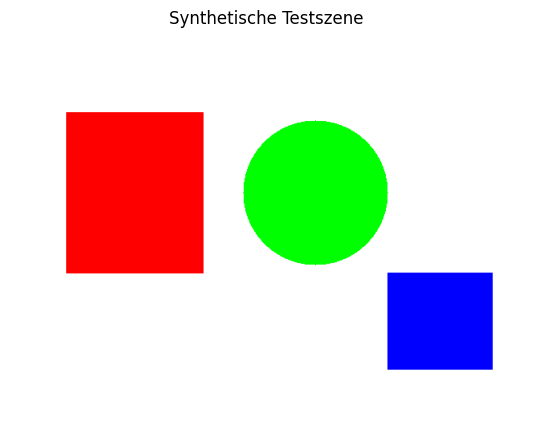

In [ ]:
image = np.full((480, 640, 3), 255, dtype=np.uint8)

cv2.rectangle(image, (70, 100), (240, 300), (0, 0, 255), -1)       # Rot in BGR
cv2.circle(image, (380, 200), 90, (0, 255, 0), -1)                # Grün
cv2.rectangle(image, (470, 300), (600, 420), (255, 0, 0), -1)     # Blau

show_image(image, "Synthetische Testszene")

Der folgende Code gibt grundlegende Eigenschaften des Bildes wie Größe, Datentyp und Anzahl der Dimensionen aus und liest beispielhaft die Farbwerte einzelner Pixel aus.

In [ ]:
print("shape:", image.shape)
print("dtype:", image.dtype)
print("Anzahl Dimensionen:", image.ndim)
print("Pixel [0, 0]:", image[0, 0])
print("Pixel [200, 380]:", image[200, 380])

shape: (480, 640, 3)
dtype: uint8
Anzahl Dimensionen: 3
Pixel [0, 0]: [255 255 255]
Pixel [200, 380]: [  0 255   0]


### Wichtig: Indizierung

OpenCV/NumPy greifen auf ein Bild typischerweise mit

```python
image[y, x]
```

zu.

- erster Index: **Zeile / y-Koordinate**
- zweiter Index: **Spalte / x-Koordinate**

Der Ursprung \((0,0)\) liegt oben links.

### Probieren Sie selbst

1. Lesen Sie einen Pixel aus dem roten Rechteck aus.
2. Lesen Sie einen Pixel aus dem blauen Rechteck aus.
3. Ändern Sie einen kleinen Bildbereich auf Weiß.
4. Zeigen Sie das veränderte Bild an.


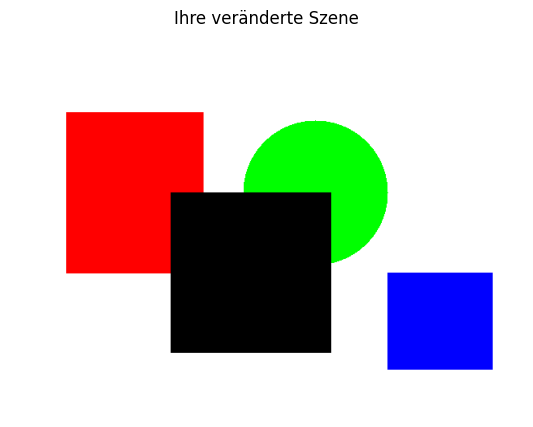

In [ ]:
# TODO: Experimentieren Sie hier.
image_modified = image.copy()

# Beispiel:
# print(image[y, x])
# Pixel im Bereich [200:400, 200:400] Null/Schwarz ersetzen: image_modified[200:400, 200:400] = 0
# Pixel im Bereich [100:500, 100:500] 255/Weiß ersetzen: image_modified[100:500, 100:500] = 255
# Pixel im Bereich [200:400, 200:400] Türkis ersetzen: image_modified[200:400, 200:400] = [200, 255, 0]


show_image(image_modified, "Ihre veränderte Szene")

## 2. Farbkanäle: BGR und RGB

Eine Kamera liefert pro Pixel mehrere Farbwerte. OpenCV verwendet für Farbbilder standardmäßig die Reihenfolge

$
[B,\;G,\;R].
$

Das ist wichtig, weil viele andere Bibliotheken und Bildformate Farben als RGB interpretieren.

RGB bzw. BGR basiert auf der additiven Farbmischung: Eine Farbe entsteht durch die Kombination unterschiedlicher Anteile von Rot, Grün und Blau. Sind alle drei Farbanteile maximal, entsteht Weiß; sind alle drei null, entsteht Schwarz.

Beispielsweise gilt für ein 8-Bit-Bild:

Schwarz: $[  0,   0,   0]$

Weiß:    $[255, 255, 255]$

Ein weißer Bildbereich besitzt daher in allen drei Farbkanälen hohe Werte. Wird das Bild anschließend in einzelne B-, G- und R-Kanäle zerlegt, erscheint der weiße Hintergrund entsprechend in allen drei Kanalbildern hell. Ein rein rotes Objekt erscheint dagegen hauptsächlich im Rot-Kanal hell.

Wenn Sie den unteren Code ausführen sehen Sie die segmentierten Fabrkanäle (monochrome dargestellt) des Bildes *image* welches Sie oben erstellt haben.

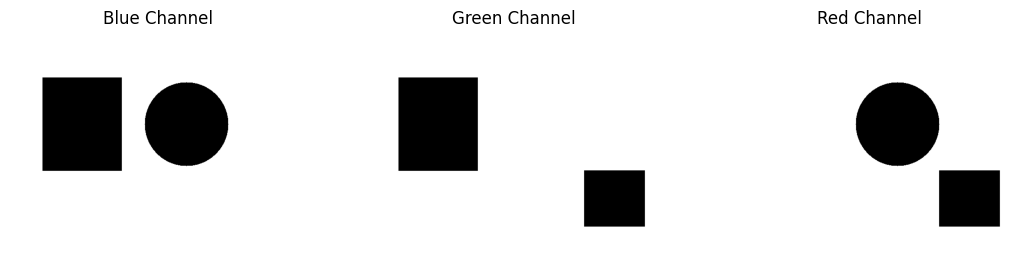

In [ ]:
b, g, r = cv2.split(image)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(b, cmap="gray"); axes[0].set_title("Blue Channel")
axes[1].imshow(g, cmap="gray"); axes[1].set_title("Green Channel")
axes[2].imshow(r, cmap="gray"); axes[2].set_title("Red Channel")
for ax in axes:
    ax.axis("off")
plt.show()

### Probieren Sie selbst

Setzen Sie einen Farbkanal vollständig auf Null und betrachten Sie das Resultat.

Welche Farbe verschwindet? Welche Farben bleiben sichtbar?


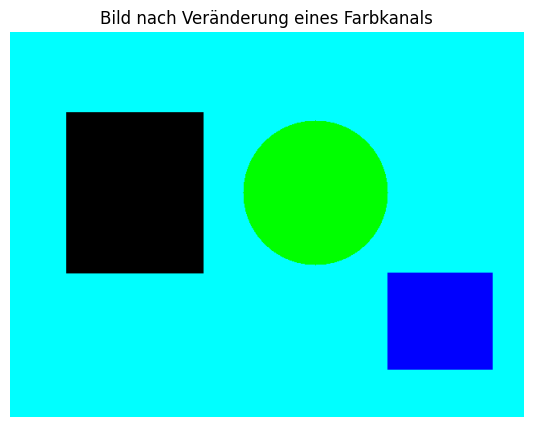

In [ ]:
test = image.copy()

# TODO: Wählen Sie einen Kanal und setzen Sie ihn auf 0.
# test[:, :, Kanal] --> Kanal = 0, 1, 2 (B, G, R)
test[:, :, 2] = 0

show_image(test, "Bild nach Veränderung eines Farbkanals")

## 3. HSV-Farbraum

RGB/BGR beschreibt eine Farbe über ihre Farbanteile. HSV trennt die Information anders:

- **H – Hue:** Farbton
- **S – Saturation:** Sättigung
- **V – Value:** Helligkeit

Das kann z.B. für einfache Farbsegmentierung nützlich sein.

Die Berechnung des HSV-Farbraum in OpenCV ([Docs](https://docs.opencv.org/4.12.0/de/d25/imgproc_color_conversions.html#autotoc_md143))

$V = \max(R,G,B)$

$S =
\begin{cases}
\dfrac{V-\min(R,G,B)}{V}, & \text{if } V \neq 0,\\
0, & \text{otherwise}
\end{cases}$

$H =
\begin{cases}
60\dfrac{G-B}{V-\min(R,G,B)}, & \text{if } V=R,\\
120 + 60\dfrac{B-R}{V-\min(R,G,B)}, & \text{if } V=G,\\
240 + 60\dfrac{R-G}{V-\min(R,G,B)}, & \text{if } V=B,\\
0, & \text{if } R=G=B
\end{cases}$

$H < 0 \;\Rightarrow\; H \leftarrow H + 360$

Für 8-Bit-Bilder:

$V \leftarrow 255 * V, \qquad
S \leftarrow 255 * S, \qquad
H \leftarrow \dfrac{H}{2}$

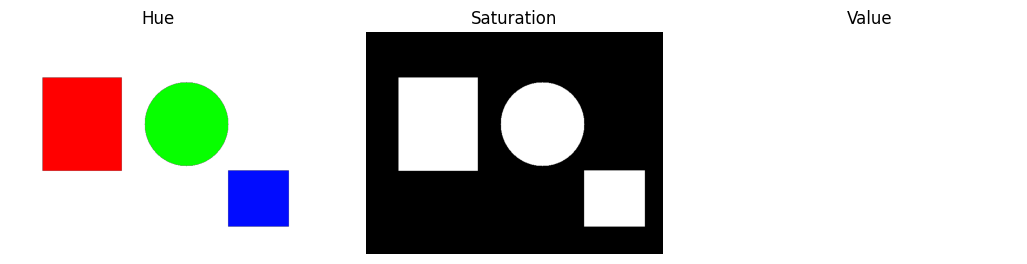

In [ ]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# Pixel mit sehr geringer Sättigung ausblenden.
# Für Weiß, Grau und Schwarz ist der Hue-Wert nicht sinnvoll interpretierbar.
h_masked = np.ma.masked_where(s < 10, h)

# Eine Abbildung mit drei Teilplots für H, S und V erzeugen
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Hue-Kanal anzeigen.
# OpenCV verwendet für Hue Werte von 0 bis 179.
axes[0].imshow(h_masked, cmap="hsv", vmin=0, vmax=179)
axes[0].set_title("Hue")

# Saturation-Kanal als Grauwertbild anzeigen.
# Hohe Werte entsprechen stark gesättigten Farben.
axes[1].imshow(s, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Saturation")

# Value-Kanal als Grauwertbild anzeigen.
# Hohe Werte entsprechen hellen Bildbereichen.
axes[2].imshow(v, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Value")

for ax in axes:
    ax.axis("off")
plt.show()

### Einfache Farbsegmentierung

Wir wollen nun nur das **grüne Objekt** auswählen. Dazu definieren wir einen Bereich im HSV-Raum und erzeugen eine Binärmaske.

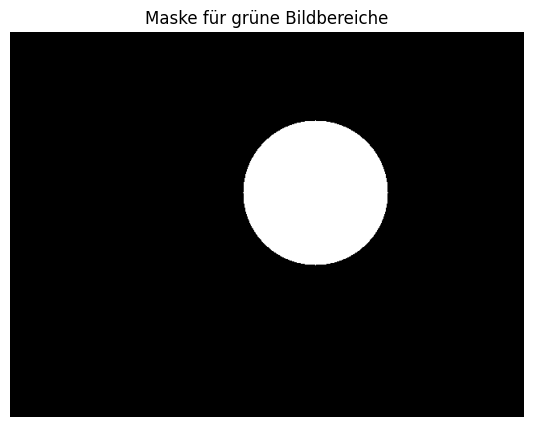

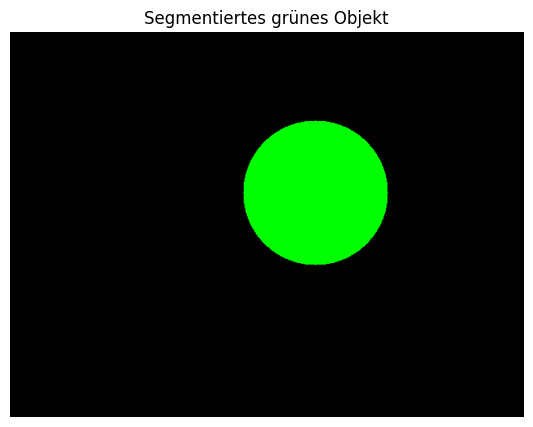

In [ ]:
# Definieren der Limits im HSV-Farbraum
# threshold = np.array([H, S, V], dtype=np.uint8)
lower_green = np.array([45, 100, 100], dtype=np.uint8)
upper_green = np.array([85, 255, 255], dtype=np.uint8)

# Maske für Pixelwerte innerhalb des definierten Farbraum
mask_green = cv2.inRange(hsv, lower_green, upper_green)
# Segmentiertes Objekt
segmented_green = cv2.bitwise_and(image, image, mask=mask_green)

show_image(mask_green, "Maske für grüne Bildbereiche", cmap="gray")
show_image(segmented_green, "Segmentiertes grünes Objekt")

### Mini-Aufgabe: Segmentieren Sie eine andere Farbe

Passen Sie die HSV-Grenzen so an, dass statt des grünen Kreises

- das blaue Rechteck **oder**
- das rote Rechteck

segmentiert wird.


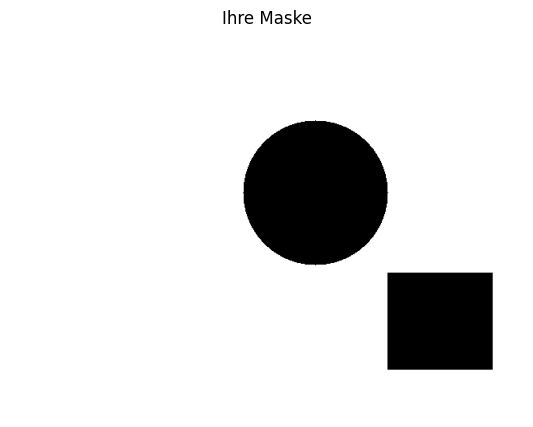

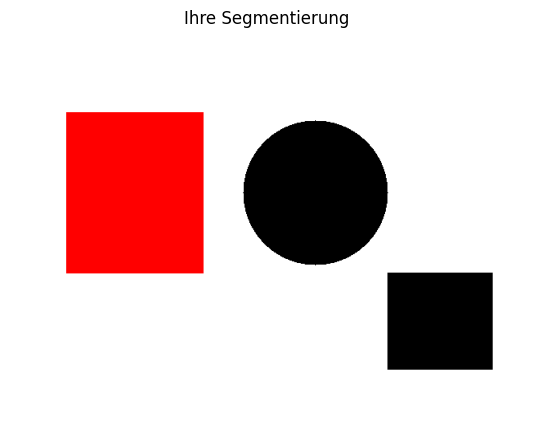

In [ ]:
# TODO: HSV-Grenzen festlegen
lower = np.array([0, 0, 0], dtype=np.uint8)
upper = np.array([0, 255, 255], dtype=np.uint8)

mask = cv2.inRange(hsv, lower, upper)
result = cv2.bitwise_and(image, image, mask=mask)

show_image(mask, "Ihre Maske", cmap="gray")
show_image(result, "Ihre Segmentierung")


## 4. Intrinsische Kameraparameter

Für die Projektion eines 3D-Punktes in das Bild benötigen wir die intrinsische Kameramatrix

$
K =
\begin{bmatrix}
f_x & 0 & c_x \\
0 & f_y & c_y \\
0 & 0 & 1
\end{bmatrix}.
$

Dabei beschreiben

- \(f_x, f_y\): Brennweite in Pixel,
- \(c_x, c_y\): Hauptpunkt des Bildes.

Für dieses Beispiel nehmen wir an, dass die Kamera bereits kalibriert wurde.

In [ ]:
fx = 600.0
fy = 600.0
cx = 320.0
cy = 240.0

K = np.array([
    [fx, 0.0, cx],
    [0.0, fy, cy],
    [0.0, 0.0, 1.0]
])

print("K =")
print(K)

K =
[[600.   0. 320.]
 [  0. 600. 240.]
 [  0.   0.   1.]]


### 3D → 2D Projektion

Ein Punkt im Kamerakoordinatensystem

$
P_c = \begin{bmatrix} X \\ Y \\ Z \end{bmatrix}
$

wird auf einen Pixel $(u,v)$ projiziert. Für das einfache Lochkameramodell gilt:

$
u = f_x \frac{X}{Z} + c_x
$

$
v = f_y \frac{Y}{Z} + c_y.
$


In [ ]:
X = 0.10
Y = 0.05
Z = 1.00

u = fx * X / Z + cx
v = fy * Y / Z + cy

print(f"3D-Punkt: X={X:.3f} m, Y={Y:.3f} m, Z={Z:.3f} m")
print(f"Projizierter Pixel: u={u:.2f}, v={v:.2f}")

3D-Punkt: X=0.100 m, Y=0.050 m, Z=1.000 m
Projizierter Pixel: u=380.00, v=270.00


### Probieren Sie selbst

Verändern Sie einzeln X, Y, Z, $f_x$ oder $f_y$ und beobachten Sie, wie sich der Bildpunkt verändert.

Überlegen Sie **vor** dem Ausführen:

- Was passiert mit $u$, wenn X größer wird?
- Was passiert mit dem Abstand zum Hauptpunkt, wenn Z größer wird?
- Welche Wirkung hat eine größere Brennweite?


In [ ]:
X_test = 0.10
Y_test = 0.05
Z_test = 1.00
fx_test = fx
fy_test = fy

u_test = fx_test * X_test / Z_test + cx
v_test = fy_test * Y_test / Z_test + cy

print(f"u={u_test:.2f}, v={v_test:.2f}")

u=380.00, v=270.00


## 5. Tiefe als zusätzliche Information

Ein normales Kamerabild liefert zunächst 2D-Bildkoordinaten $(u,v)$. Ein Tiefensensor ergänzt für einen Bildpunkt einen Tiefenwert Z:

$
(u,v) \rightarrow (u,v,Z)
$

Mit der Kameramatrix kann daraus ein 3D-Punkt im Kamerakoordinatensystem rekonstruiert werden.

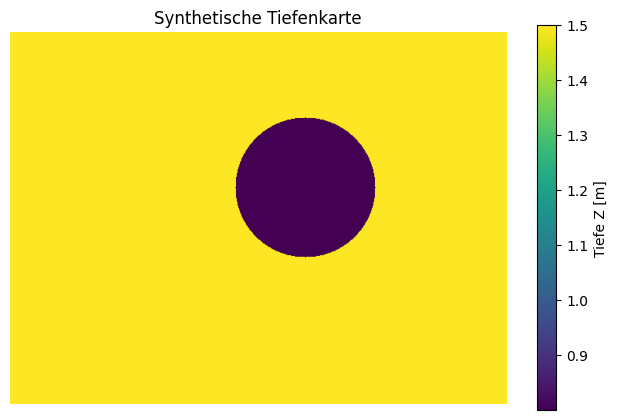

Tiefe im Hintergrund: 1.5 m
Tiefe im Kreis: 0.8 m


In [ ]:
height, width = 480, 640

depth = np.full((height, width), 1.5, dtype=np.float32)
yy, xx = np.ogrid[:height, :width]
circle = (xx - 380)**2 + (yy - 200)**2 <= 90**2
depth[circle] = 0.8

plt.figure(figsize=(8, 5))
im = plt.imshow(depth, cmap="viridis")
plt.colorbar(im, label="Tiefe Z [m]")
plt.title("Synthetische Tiefenkarte")
plt.axis("off")
plt.show()

print("Tiefe im Hintergrund:", depth[50, 50], "m")
print("Tiefe im Kreis:", depth[200, 380], "m")

### 2D + Tiefe → 3D

Aus Pixelkoordinaten und Tiefe folgt für das Lochkameramodell:

$
X = \frac{(u-c_x)Z}{f_x}
$

$
Y = \frac{(v-c_y)Z}{f_y}.
$

Damit wird aus einem Pixel wieder ein 3D-Punkt relativ zur Kamera.

In [ ]:
u = 380.0
v = 200.0
Z = float(depth[int(v), int(u)])

X = (u - cx) * Z / fx
Y = (v - cy) * Z / fy

point_3d = np.array([X, Y, Z])

print("Pixel (u, v):", (u, v))
print(f"Tiefe Z: {Z:.2f} m")
print(f"3D-Punkt [X, Y, Z]: [{X:.3f}, {Y:.3f}, {Z:.3f}] m")

Pixel (u, v): (380.0, 200.0)
Tiefe Z: 0.80 m
3D-Punkt [X, Y, Z]: [0.080, -0.053, 0.800] m


## 6. Mini-Aufgabe: Hin und zurück

Wählen Sie selbst einen gültigen Pixel $(u,v)$ aus der Tiefenkarte.

1. Lesen Sie dessen Tiefenwert Z aus.
2. Rekonstruieren Sie daraus (X,Y,Z).
3. Projizieren Sie diesen 3D-Punkt wieder in das Bild.
4. Vergleichen Sie den resultierenden Pixel mit dem ursprünglichen Pixel.

Wenn das Kameramodell konsistent angewendet wurde, sollten beide Bildpunkte nahezu identisch sein.

In [ ]:
# TODO: Eigenen Pixel wählen
u0 = 300.0
v0 = 250.0

Z0 = float(depth[int(v0), int(u0)])
X0 = (u0 - cx) * Z0 / fx
Y0 = (v0 - cy) * Z0 / fy

u_back = fx * X0 / Z0 + cx
v_back = fy * Y0 / Z0 + cy

print("Original:", (u0, v0))
print("3D-Punkt:", (X0, Y0, Z0))
print("Rückprojektion:", (u_back, v_back))
print("Fehler [Pixel]:", np.linalg.norm([u_back-u0, v_back-v0]))

Original: (300.0, 250.0)
3D-Punkt: (-0.05, 0.025, 1.5)
Rückprojektion: (300.0, 250.0)
Fehler [Pixel]: 0.0


## 7. Selbstcheck

Beantworten Sie die Fragen zunächst ohne in die Folien zu schauen.

1. Warum ist `image[y, x]` und nicht `image[x, y]` üblich?
2. In welcher Kanalreihenfolge speichert OpenCV ein Farbbild standardmäßig?
3. Warum kann HSV für Farbsegmentierung praktisch sein?
4. Welche Bedeutung haben $f_x, f_y, c_x, c_y$?
5. Warum reicht ein einzelner Pixel (u,v) nicht aus, um einen eindeutigen 3D-Punkt zu bestimmen?
6. Was passiert mit der Bildposition eines Punktes, wenn seine Tiefe Z größer wird, X und Y aber gleich bleiben?

<details>
<summary><b>Kurze Antworten anzeigen</b></summary>

1. NumPy organisiert ein Bild als Zeilen und Spalten. Daher wird zuerst die Zeile y, danach die Spalte x angegeben.
2. BGR.
3. Farbton, Sättigung und Helligkeit sind getrennt. Dadurch können bestimmte Farben oft einfacher über Schwellwerte ausgewählt werden.
4. \(f_x,f_y\) beschreiben die Brennweite in Pixel; \(c_x,c_y\) den Hauptpunkt.
5. Entlang des Sehstrahls liegen unendlich viele mögliche 3D-Punkte. Es fehlt die Tiefe.
6. Der Punkt wandert näher zum Hauptpunkt, da \(X/Z\) und \(Y/Z\) kleiner werden.

</details>

## 8. Take-away

Für die Präsenz-LV sollten Sie folgende Punkte mitnehmen:

- Ein Sensor liefert zunächst **numerische Messwerte**, keine Objektinformation.
- Ein digitales Bild ist ein Array aus Pixelwerten.
- Die Wahl des Farbraums beeinflusst, wie leicht bestimmte Bildinformationen verarbeitet werden können.
- Die intrinsische Kameramatrix beschreibt die Abbildung von Kamerakoordinaten auf Pixelkoordinaten.
- Ein Tiefenwert ergänzt die 2D-Bildinformation um die Information, die für eine Rekonstruktion eines 3D-Punktes benötigt wird.

### Ausblick

In der ersten Hausübung führen Sie anschließend selbstständig eine **Kamerakalibrierung mit OpenCV 4.12** durch und bestimmen die intrinsischen Kameraparameter Ihrer Kamera.